<a href="https://colab.research.google.com/github/AndrasBajnokSzabo/kaggle-petfinder-adoption-prediction/blob/main/notebooks/petfinder_data_quality_and_features.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files

# This will prompt you to select a file. Choose the kaggle.json you downloaded.
files.upload()

# Set up the Kaggle directory and permissions
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Download and unzip the PetFinder dataset
!kaggle competitions download -c petfinder-adoption-prediction
!unzip -q petfinder-adoption-prediction.zip

Saving kaggle.json to kaggle.json
100% 1.94G/1.94G [01:31<00:00, 22.8MB/s]



In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Main table: one row = one pet profile (listing)
train = pd.read_csv('train/train.csv')
test = pd.read_csv('test/test.csv')

# Label files: translate the numeric codes into names
breeds = pd.read_csv('breed_labels.csv')   # BreedID -> BreedName (+ dog/cat)
colors = pd.read_csv('color_labels.csv')   # ColorID -> ColorName
states = pd.read_csv('state_labels.csv')   # StateID -> StateName

print('train:', train.shape)
print('test: ', test.shape)
display(train.head())

train: (14993, 24)
test:  (3972, 23)


,Type,Name,Age,Breed1,Breed2,Gender,Color1,Color2,Color3,MaturitySize,...,Health,Quantity,Fee,State,RescuerID,VideoAmt,Description,PetID,PhotoAmt,AdoptionSpeed
0,2,Nibble,3,299,0,1,1,7,0,1,...,1,1,100,41326,8480853f516546f6cf33aa88cd76c379,0,Nibble is a 3+ month old ball of cuteness. He ...,86e1089a3,1.0,2
1,2,No Name Yet,1,265,0,1,1,2,0,2,...,1,1,0,41401,3082c7125d8fb66f7dd4bff4192c8b14,0,I just found it alone yesterday near my apartm...,6296e909a,2.0,0
2,1,Brisco,1,307,0,1,2,7,0,2,...,1,1,0,41326,fa90fa5b1ee11c86938398b60abc32cb,0,Their pregnant mother was dumped by her irresp...,3422e4906,7.0,3
3,1,Miko,4,307,0,2,1,2,0,2,...,1,1,150,41401,9238e4f44c71a75282e62f7136c6b240,0,"Good guard dog, very alert, active, obedience ...",5842f1ff5,8.0,2
4,1,Hunter,1,307,0,1,1,0,0,2,...,1,1,0,41326,95481e953f8aed9ec3d16fc4509537e8,0,This handsome yet cute boy is up for adoption....,850a43f90,3.0,2


In [ ]:
# Explicit missing values (NaN) per column
missing = train.isna().sum()
missing_table = pd.DataFrame({
    'missing': missing,
    'percent': (missing / len(train) * 100).round(2),
})
missing_table[missing_table['missing'] > 0]

,missing,percent
Name,1265,8.44
Description,13,0.09


In [ ]:
# Codes that mean "unknown" according to the data description
unknown_codes = {
    'MaturitySize': 0,  # 0 = Not Specified
    'FurLength': 0,     # 0 = Not Specified
    'Health': 0,        # 0 = Not Specified
    'Vaccinated': 3,    # 3 = Not Sure
    'Dewormed': 3,      # 3 = Not Sure
    'Sterilized': 3,    # 3 = Not Sure
}

hidden = pd.DataFrame({
    'unknown code': unknown_codes,
    'count': {col: (train[col] == code).sum() for col, code in unknown_codes.items()},
})
hidden['percent'] = (hidden['count'] / len(train) * 100).round(2)
hidden

,unknown code,count,percent
MaturitySize,0,0,0.00
FurLength,0,0,0.00
Health,0,0,0.00
Vaccinated,3,1868,12.46
Dewormed,3,1781,11.88
Sterilized,3,1815,12.11


In [ ]:
# Row level: count NaN + "unknown" codes in each row
missing_mask = train.isna()
for col, code in unknown_codes.items():
    missing_mask[col] = missing_mask[col] | (train[col] == code)

missing_per_row = missing_mask.sum(axis=1)

row_summary = missing_per_row.value_counts().sort_index().to_frame('rows')
row_summary['percent'] = (row_summary['rows'] / len(train) * 100).round(2)
row_summary.index.name = 'missing values in row'
row_summary

,rows,percent
missing values in row,,
0,11325,75.54
1,1828,12.19
2,776,5.18
3,894,5.96
4,170,1.13


In [ ]:
numeric_cols = ['Age', 'Quantity', 'Fee', 'VideoAmt', 'PhotoAmt']

q1 = train[numeric_cols].quantile(0.25)
q3 = train[numeric_cols].quantile(0.75)
iqr = q3 - q1
upper = q3 + 1.5 * iqr
lower = q1 - 1.5 * iqr

n_outliers = ((train[numeric_cols] < lower) | (train[numeric_cols] > upper)).sum()

quartiles = pd.DataFrame({
    'min': train[numeric_cols].min(),
    'Q1': q1, 'median': train[numeric_cols].median(), 'Q3': q3,
    'max': train[numeric_cols].max(),
    'IQR': iqr, 'upper fence': upper,
    'outliers': n_outliers,
    'outlier %': (n_outliers / len(train) * 100).round(2),
})
quartiles

,min,Q1,median,Q3,max,IQR,upper fence,outliers,outlier %
Age,0.0,2.0,3.0,12.0,255.0,10.0,27.0,1501,10.01
Quantity,1.0,1.0,1.0,1.0,20.0,0.0,1.0,3428,22.86
Fee,0.0,0.0,0.0,0.0,3000.0,0.0,0.0,2330,15.54
VideoAmt,0.0,0.0,0.0,0.0,8.0,0.0,0.0,574,3.83
PhotoAmt,0.0,2.0,3.0,5.0,30.0,3.0,9.5,922,6.15


In [ ]:
# Allowed values of each coded column (data description + label files)
allowed = {
    'Type':          {1, 2},
    'Gender':        {1, 2, 3},
    'MaturitySize':  {0, 1, 2, 3, 4},
    'FurLength':     {0, 1, 2, 3},
    'Vaccinated':    {1, 2, 3},
    'Dewormed':      {1, 2, 3},
    'Sterilized':    {1, 2, 3},
    'Health':        {0, 1, 2, 3},
    'AdoptionSpeed': {0, 1, 2, 3, 4},
    'Breed1':        set(breeds['BreedID']),
    'Breed2':        set(breeds['BreedID']) | {0},   # 0 = no second breed
    'Color1':        set(colors['ColorID']),
    'Color2':        set(colors['ColorID']) | {0},   # 0 = no second colour
    'Color3':        set(colors['ColorID']) | {0},
    'State':         set(states['StateID']),
}

validity = pd.DataFrame([
    {
        'column': col,
        'allowed values': len(ok),
        'used values': train[col].nunique(),
        'invalid rows': (~train[col].isin(ok)).sum(),
        'invalid codes': sorted(int(v) for v in set(train[col]) - ok),
    }
    for col, ok in allowed.items()
]).set_index('column')
validity

,allowed values,used values,invalid rows,invalid codes
column,,,,
Type,2,2,0,[]
Gender,3,3,0,[]
MaturitySize,5,4,0,[]
FurLength,4,3,0,[]
Vaccinated,3,3,0,[]
Dewormed,3,3,0,[]
Sterilized,3,3,0,[]
Health,4,3,0,[]
AdoptionSpeed,5,5,0,[]


In [ ]:
breed_type = breeds.set_index('BreedID')['Type']       # 1 = dog breed, 2 = cat breed
breed_name = breeds.set_index('BreedID')['BreedName']

expected_type = train['Breed1'].map(breed_type)        # NaN where Breed1 is not a valid ID
type_mismatch = expected_type.notna() & (expected_type != train['Type'])
print('Breed1 belongs to the other animal type:', type_mismatch.sum(), 'rows')

# Which breeds are involved?
(train.loc[type_mismatch, ['Type', 'Breed1']]
      .assign(BreedName=train['Breed1'].map(breed_name))
      .value_counts()
      .head(10))

Breed1 belongs to the other animal type: 12 rows


Type  Breed1  BreedName                 
2     307     Mixed Breed                   4
      25      Belgian Shepherd Laekenois    2
      21      Bearded Collie                1
      15      Australian Kelpie             1
      70      Collie                        1
      114     Greyhound                     1
      205     Shih Tzu                      1
      218     Terrier                       1
Name: count, dtype: int64

In [ ]:
print('PetID unique in train:', train['PetID'].is_unique)
print('Duplicated PetIDs:', train['PetID'].duplicated().sum())
print('PetIDs in both train and test:', train['PetID'].isin(test['PetID']).sum())

PetID unique in train: True
Duplicated PetIDs: 0
PetIDs in both train and test: 0


In [ ]:
#Rows that are identical in every respect, except for the PetID:

cols_without_id = train.columns.drop('PetID')
dup = train.duplicated(subset=cols_without_id, keep=False)   # keep=False marks every copy
print('Rows that have an identical copy (apart from PetID):', dup.sum())
train[dup].sort_values(['RescuerID', 'Name']).head(10)

Rows that have an identical copy (apart from PetID): 16


,Type,Name,Age,Breed1,Breed2,Gender,Color1,Color2,Color3,MaturitySize,...,Health,Quantity,Fee,State,RescuerID,VideoAmt,Description,PetID,PhotoAmt,AdoptionSpeed
4709,1,NaN,12,307,0,2,2,3,7,1,...,1,1,0,41330,096cdf8460684e818fc5929c5f5462cf,0,There is a female dog wandering around Taman B...,902624c4b,5.0,2
8802,1,NaN,12,307,0,2,2,3,7,1,...,1,1,0,41330,096cdf8460684e818fc5929c5f5462cf,0,There is a female dog wandering around Taman B...,a07440416,5.0,2
6359,2,NaN,1,266,266,3,1,6,7,2,...,1,5,0,41326,0b65c9795c3f969870365b68c102fb81,0,Assalamualaikum.. Mohon jasa baik anda.... Ada...,5174e0542,1.0,4
12626,2,NaN,1,266,266,3,1,6,7,2,...,1,5,0,41326,0b65c9795c3f969870365b68c102fb81,0,Assalamualaikum.. Mohon jasa baik anda.... Ada...,d0c3c032a,1.0,4
4350,1,NaN,1,307,0,3,2,7,0,1,...,1,5,0,41326,5ac31b8484313639bf6240562cbbf896,0,Their mother seeked refuge under our cover dra...,0e49eebb3,2.0,4
13150,1,NaN,1,307,0,3,2,7,0,1,...,1,5,0,41326,5ac31b8484313639bf6240562cbbf896,0,Their mother seeked refuge under our cover dra...,ae089cd20,2.0,4
8250,1,NaN,10,197,307,2,7,0,0,2,...,1,2,0,41401,695eed7c60628e8a051be03dfadb3092,0,I found them yesterday at Lekas highway beside...,63cd0b2b3,5.0,2
11016,1,NaN,10,197,307,2,7,0,0,2,...,1,2,0,41401,695eed7c60628e8a051be03dfadb3092,0,I found them yesterday at Lekas highway beside...,91c4cb54d,5.0,2
7193,1,NaN,16,307,0,3,2,4,7,2,...,1,5,0,41327,6a63225c99e15e616e0118ffba7e8107,0,I am not willing to give up to feed them. but ...,c67d871e3,5.0,4
7653,1,NaN,16,307,0,3,2,4,7,2,...,1,5,0,41327,6a63225c99e15e616e0118ffba7e8107,0,I am not willing to give up to feed them. but ...,b6a16ab86,5.0,4


In [ ]:
# RescuerID
per_rescuer = train['RescuerID'].value_counts()
print('Number of rescuers:', per_rescuer.size)
print(per_rescuer.describe())
print('Top 10 rescuers posted', round(per_rescuer.head(10).sum() / len(train) * 100, 1), '% of listings')
print('Train rows whose rescuer also appears in test:', train['RescuerID'].isin(test['RescuerID']).sum())

Number of rescuers: 5595
count    5595.000000
mean        2.679714
std        10.384820
min         1.000000
25%         1.000000
50%         1.000000
75%         2.000000
max       459.000000
Name: count, dtype: float64
Top 10 rescuers posted 12.7 % of listings
Train rows whose rescuer also appears in test: 0


In [ ]:
# The most frequent names: placeholders like "No Name Yet" show up near the top
train['Name'].value_counts().head(20)

,count
Name,
Baby,66
Lucky,64
No Name,54
Brownie,54
Mimi,52
Blackie,49
Puppy,45
Max,39
Kittens,39


In [ ]:
# Names that are filled in but carry no information
# 1) explicit "no name" phrases (compared in lower case, so "No Name" = "no name")
placeholder_pattern = r'no name|noname|unnamed|not named|nameless|unknown'
name_lower = train['Name'].str.strip().str.lower()
is_placeholder = name_lower.str.contains(placeholder_pattern, na=False)   # na=False: NaN names -> False

# 2) names without a single letter, e.g. "1", "2" (numbering of litter-mates)
#    [^\W\d_] = any letter of any alphabet, so Chinese names are not flagged
has_no_letter = train['Name'].notna() & ~train['Name'].str.contains(r'[^\W\d_]', na=False)

print('Placeholder names      :', is_placeholder.sum())
print('Names without a letter :', has_no_letter.sum())
train.loc[is_placeholder | has_no_letter, 'Name'].value_counts().head(15)

Placeholder names      : 151
Names without a letter : 20


,count
Name,
No Name,54
No Name Yet,22
Unknown,15
Nameless,6
Unnamed,5
No Names Yet,4
Noname,3
Not Named Yet,2
(no Name),2


In [ ]:
# Rules that must hold BETWEEN columns.
# Each rule is a True/False mask: True = the row violates the rule.
b1, b2 = train['Breed1'], train['Breed2']
c1, c2, c3 = train['Color1'], train['Color2'], train['Color3']

consistency_checks = {
    # a second breed equal to the first adds no information
    'Breed2 equals Breed1':            (b2 == b1) & (b2 != 0),
    # a secondary breed without a primary one -> fields filled in the wrong order
    'Breed1 = 0 but Breed2 given':     (b1 == 0) & (b2 != 0),
    # no breed at all
    'Breed1 = 0 and Breed2 = 0':       (b1 == 0) & (b2 == 0),
    # colours are filled in order: if Color2 is empty, Color3 should be empty too
    'Color3 given but Color2 = 0':     (c2 == 0) & (c3 != 0),
    # the colours of one pet should all be different
    'Repeated colour':                 ((c2 != 0) & (c2 == c1)) | ((c3 != 0) & ((c3 == c1) | (c3 == c2))),
    # "Mixed" gender only makes sense for a group of pets
    'Gender = Mixed but Quantity = 1': (train['Gender'] == 3) & (train['Quantity'] == 1),
    # not an error: Age, Breed, Health etc. then describe a whole group
    'Group listing (Quantity > 1)':    train['Quantity'] > 1,
}

# Count the violating rows per rule
consistency = pd.DataFrame({'rows': {rule: mask.sum() for rule, mask in consistency_checks.items()}})
consistency['percent'] = (consistency['rows'] / len(train) * 100).round(2)
consistency

,rows,percent
Breed2 equals Breed1,1510,10.07
Breed1 = 0 but Breed2 given,5,0.03
Breed1 = 0 and Breed2 = 0,0,0.00
Color3 given but Color2 = 0,0,0.00
Repeated colour,0,0.00
Gender = Mixed but Quantity = 1,0,0.00
Group listing (Quantity > 1),3428,22.86


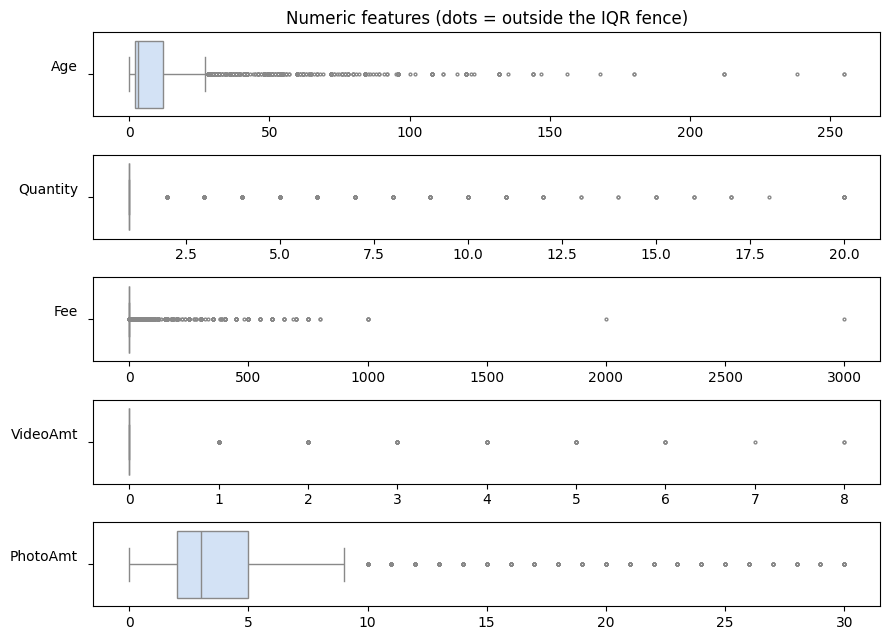

In [ ]:
# Distribution of each numeric feature as a boxplot.
# Separate subplots, because the scales are very different (Fee: 0-3000, VideoAmt: 0-8).
fig, axes = plt.subplots(len(numeric_cols), 1, figsize=(9, 6.5))
for ax, col in zip(axes, numeric_cols):
    sns.boxplot(x=train[col], ax=ax, color='#cde2fb', fliersize=2)   # dots = outside the IQR fence
    ax.set_xlabel('')
    ax.set_ylabel(col, rotation=0, ha='right')
axes[0].set_title('Numeric features (dots = outside the IQR fence)')
plt.tight_layout()
plt.show()

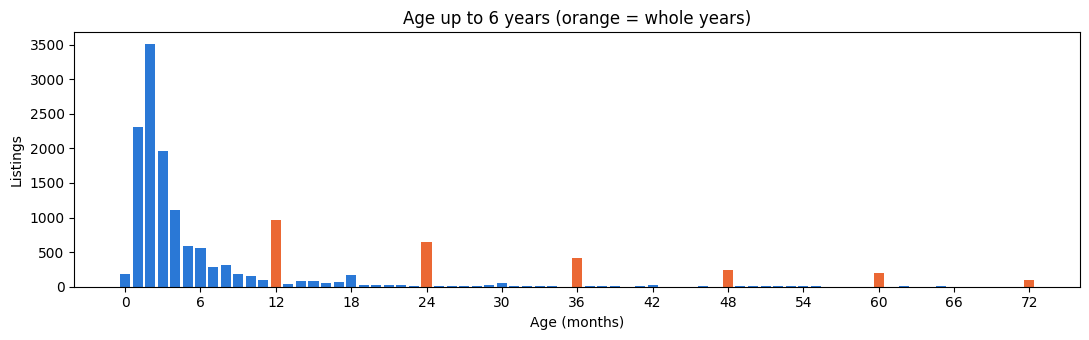

Ages >= 12 months that are a whole year: 74.6% (8.3% expected if uniform)


In [ ]:
# Age is estimated by the rescuer, so it is often rounded to whole years.
# If so, 12, 24, 36 ... months appear far more often than their neighbours.
age_counts = train['Age'].value_counts().sort_index()
age_counts = age_counts[age_counts.index <= 72]          # first 6 years, for readability

# orange = whole year, blue = any other month
bar_colors = ['#eb6834' if (age % 12 == 0 and age > 0) else '#2a78d6' for age in age_counts.index]

fig, ax = plt.subplots(figsize=(11, 3.5))
ax.bar(age_counts.index, age_counts.values, color=bar_colors)
ax.set_title('Age up to 6 years (orange = whole years)')
ax.set_xlabel('Age (months)')
ax.set_ylabel('Listings')
ax.set_xticks(range(0, 73, 6))
plt.tight_layout()
plt.show()

# If ages were spread evenly over the months, only ~1 in 12 (8.3%) would fall on a whole year
adult = train['Age'] >= 12
whole_year_share = (train.loc[adult, 'Age'] % 12 == 0).mean() * 100
print(f'Ages >= 12 months that are a whole year: {whole_year_share:.1f}% (8.3% expected if uniform)')

In [ ]:
# Domain checks: values that are possible but suspicious for a pet listing
plausibility = {
    'Age > 240 months (over 20 years)': train['Age'] > 240,
    'Age = 0 months (under 1 month)':   train['Age'] == 0,
    'Fee > 1000 MYR':                   train['Fee'] > 1000,
    'Quantity > 10':                    train['Quantity'] > 10,
    'PhotoAmt not a whole number':      train['PhotoAmt'] % 1 != 0,
}
plaus = pd.DataFrame({'rows': {check: mask.sum() for check, mask in plausibility.items()}})
plaus['percent'] = (plaus['rows'] / len(train) * 100).round(2)

# PhotoAmt is a count, but it is stored as a decimal number
print('PhotoAmt dtype:', train['PhotoAmt'].dtype)
plaus

PhotoAmt dtype: float64


,rows,percent
Age > 240 months (over 20 years),2,0.01
Age = 0 months (under 1 month),179,1.19
Fee > 1000 MYR,2,0.01
Quantity > 10,43,0.29
PhotoAmt not a whole number,0,0.00


In [ ]:
def clean_petfinder(df):
    """Apply every 'fix' decision of the summary table.
    Returns a cleaned copy; the original DataFrame is not modified.
    Works on train and test alike, so both are cleaned the same way."""
    df = df.copy()

    # 1) Breed1 empty (0) but Breed2 filled: the fields were entered in the wrong order
    swap = (df['Breed1'] == 0) & (df['Breed2'] != 0)
    df.loc[swap, 'Breed1'] = df.loc[swap, 'Breed2']
    df.loc[swap, 'Breed2'] = 0

    # 2) Breed2 equal to Breed1 adds no information -> 0 (= no second breed)
    same = (df['Breed2'] == df['Breed1']) & (df['Breed2'] != 0)
    df.loc[same, 'Breed2'] = 0

    # 3) Colour gap: Color3 filled while Color2 is empty -> move Color3 into Color2
    gap = (df['Color2'] == 0) & (df['Color3'] != 0)
    df.loc[gap, 'Color2'] = df.loc[gap, 'Color3']
    df.loc[gap, 'Color3'] = 0

    # 4) Placeholder names ("No Name Yet" ...) mean "no name" -> NaN
    name = df['Name'].str.strip()
    df['Name'] = name.mask(name.str.lower().str.contains(placeholder_pattern, na=False))

    # 5) Missing description -> empty string, so text processing never meets NaN
    df['Description'] = df['Description'].fillna('')

    # 6) PhotoAmt is a count -> integer
    df['PhotoAmt'] = df['PhotoAmt'].round().astype(int)

    return df

In [ ]:
train_clean = clean_petfinder(train)
test_clean = clean_petfinder(test)

# Verify the cleaning: every fixed problem must be gone and nothing else may change
assert len(train_clean) == len(train)                                 # no rows removed
assert train_clean['AdoptionSpeed'].equals(train['AdoptionSpeed'])    # target untouched
assert not ((train_clean['Breed1'] == 0) & (train_clean['Breed2'] != 0)).any()
assert not ((train_clean['Breed2'] == train_clean['Breed1']) & (train_clean['Breed2'] != 0)).any()
assert not ((train_clean['Color2'] == 0) & (train_clean['Color3'] != 0)).any()
assert train_clean['Description'].notna().all()
print('All fixes verified.')

# How many cells did the cleaning change in each column? (NaN -> NaN does not count as a change)
changed = (train_clean != train) & ~(train_clean.isna() & train.isna())
changed.sum()[changed.sum() > 0].to_frame('changed cells')

# **Document the dataset features and their meanings**


In [ ]:
# What pandas can tell us on its own: only the storage type of each column
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14993 entries, 0 to 14992
Data columns (total 24 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Type           14993 non-null  int64  
 1   Name           13728 non-null  object 
 2   Age            14993 non-null  int64  
 3   Breed1         14993 non-null  int64  
 4   Breed2         14993 non-null  int64  
 5   Gender         14993 non-null  int64  
 6   Color1         14993 non-null  int64  
 7   Color2         14993 non-null  int64  
 8   Color3         14993 non-null  int64  
 9   MaturitySize   14993 non-null  int64  
 10  FurLength      14993 non-null  int64  
 11  Vaccinated     14993 non-null  int64  
 12  Dewormed       14993 non-null  int64  
 13  Sterilized     14993 non-null  int64  
 14  Health         14993 non-null  int64  
 15  Quantity       14993 non-null  int64  
 16  Fee            14993 non-null  int64  
 17  State          14993 non-null  int64  
 18  Rescue

In [ ]:
# Feature overview: one row per column of train.csv.
# Meanings are taken from the Kaggle data description (Data tab of the competition page).
feature_info = pd.DataFrame([
    # (feature, type, meaning)

    # identifiers: hash IDs, not features in themselves
    ('PetID',         'identifier',            'Unique hash ID of the pet profile'),
    ('RescuerID',     'identifier',            'Unique hash ID of the rescuer (person or shelter)'),

    # target: the value to predict
    ('AdoptionSpeed', 'target (ordinal)',      'Speed of adoption: 0 = same day, 1 = 1-7 days, 2 = 8-30 days, '
                                               '3 = 31-90 days, 4 = not adopted after 100 days (lower = faster)'),

    # binary: exactly two possible values
    ('Type',          'binary',                'Type of animal (1 = Dog, 2 = Cat)'),

    # categorical without a natural order (nominal)
    ('Gender',        'categorical (nominal)', 'Gender (1 = Male, 2 = Female, 3 = Mixed, if the profile is a group)'),
    ('Breed1',        'categorical (nominal)', 'Primary breed (BreedID from breed_labels.csv)'),
    ('Breed2',        'categorical (nominal)', 'Secondary breed, if mixed breed (BreedID, 0 = none)'),
    ('Color1',        'categorical (nominal)', 'Colour 1 (ColorID from color_labels.csv)'),
    ('Color2',        'categorical (nominal)', 'Colour 2 (ColorID, 0 = none)'),
    ('Color3',        'categorical (nominal)', 'Colour 3 (ColorID, 0 = none)'),
    ('State',         'categorical (nominal)', 'State in Malaysia (StateID from state_labels.csv)'),
    ('Vaccinated',    'categorical (nominal)', 'Has been vaccinated (1 = Yes, 2 = No, 3 = Not Sure)'),
    ('Dewormed',      'categorical (nominal)', 'Has been dewormed (1 = Yes, 2 = No, 3 = Not Sure)'),
    ('Sterilized',    'categorical (nominal)', 'Has been spayed / neutered (1 = Yes, 2 = No, 3 = Not Sure)'),

    # categorical with a natural order (ordinal)
    ('MaturitySize',  'categorical (ordinal)', 'Size at maturity (1 = Small, 2 = Medium, 3 = Large, 4 = Extra Large, 0 = Not Specified)'),
    ('FurLength',     'categorical (ordinal)', 'Fur length (1 = Short, 2 = Medium, 3 = Long, 0 = Not Specified)'),
    ('Health',        'categorical (ordinal)', 'Health condition (1 = Healthy, 2 = Minor Injury, 3 = Serious Injury, 0 = Not Specified)'),

    # numerical: counts and amounts
    ('Age',           'numerical',             'Age when listed, in months'),
    ('Quantity',      'numerical',             'Number of pets represented in the profile'),
    ('Fee',           'numerical',             'Adoption fee (0 = free)'),
    ('VideoAmt',      'numerical',             'Number of uploaded videos'),
    ('PhotoAmt',      'numerical',             'Number of uploaded photos'),

    # free text
    ('Name',          'text',                  'Name of the pet (empty if not named)'),
    ('Description',   'text',                  'Profile write-up; mostly English, some Malay or Chinese'),
], columns=['feature', 'type', 'meaning'])

# Sanity check: every column of train.csv is described exactly once
assert sorted(feature_info['feature']) == sorted(train.columns)

# Add facts measured on the data
feature_info['pandas dtype']  = feature_info['feature'].map(train.dtypes.astype(str))   # how pandas stores it
feature_info['unique values'] = feature_info['feature'].map(train.nunique())
feature_info['missing (NaN)'] = feature_info['feature'].map(train.isna().sum())
feature_info['example']       = feature_info['feature'].map(lambda col: str(train[col].dropna().iloc[0])[:30])

pd.set_option('display.max_colwidth', 120)   # show the full meaning text
feature_info

,feature,type,meaning,pandas dtype,unique values,missing (NaN),example
0,PetID,identifier,Unique hash ID of the pet profile,object,14993,0,86e1089a3
1,RescuerID,identifier,Unique hash ID of the rescuer (person or shelter),object,5595,0,8480853f516546f6cf33aa88cd76c3
2,AdoptionSpeed,target (ordinal),"Speed of adoption: 0 = same day, 1 = 1-7 days, 2 = 8-30 days, 3 = 31-90 days, 4 = not adopted after 100 days (lower ...",int64,5,0,2
3,Type,binary,"Type of animal (1 = Dog, 2 = Cat)",int64,2,0,2
4,Gender,categorical (nominal),"Gender (1 = Male, 2 = Female, 3 = Mixed, if the profile is a group)",int64,3,0,1
5,Breed1,categorical (nominal),Primary breed (BreedID from breed_labels.csv),int64,176,0,299
6,Breed2,categorical (nominal),"Secondary breed, if mixed breed (BreedID, 0 = none)",int64,135,0,0
7,Color1,categorical (nominal),Colour 1 (ColorID from color_labels.csv),int64,7,0,1
8,Color2,categorical (nominal),"Colour 2 (ColorID, 0 = none)",int64,7,0,7
9,Color3,categorical (nominal),"Colour 3 (ColorID, 0 = none)",int64,6,0,0


In [ ]:
# Features grouped by type
feature_info.groupby('type', sort=False)['feature'].apply(', '.join).to_frame('features')

,features
type,
identifier,"PetID, RescuerID"
target (ordinal),AdoptionSpeed
binary,Type
categorical (nominal),"Gender, Breed1, Breed2, Color1, Color2, Color3, State, Vaccinated, Dewormed, Sterilized"
categorical (ordinal),"MaturitySize, FurLength, Health"
numerical,"Age, Quantity, Fee, VideoAmt, PhotoAmt"
text,"Name, Description"


In [ ]:
# Code -> meaning for every column with a short, fixed code list (from the Kaggle data description)
CODE_MAPS = {
    'Type':          {1: 'Dog', 2: 'Cat'},
    'Gender':        {1: 'Male', 2: 'Female', 3: 'Mixed (group)'},
    'MaturitySize':  {0: 'Not Specified', 1: 'Small', 2: 'Medium', 3: 'Large', 4: 'Extra Large'},
    'FurLength':     {0: 'Not Specified', 1: 'Short', 2: 'Medium', 3: 'Long'},
    'Vaccinated':    {1: 'Yes', 2: 'No', 3: 'Not Sure'},
    'Dewormed':      {1: 'Yes', 2: 'No', 3: 'Not Sure'},
    'Sterilized':    {1: 'Yes', 2: 'No', 3: 'Not Sure'},
    'Health':        {0: 'Not Specified', 1: 'Healthy', 2: 'Minor Injury', 3: 'Serious Injury'},
    'AdoptionSpeed': {0: 'Same day', 1: '1-7 days', 2: '8-30 days', 3: '31-90 days', 4: 'Not adopted (100+ days)'},
}

def encoding_table(col):
    """Code -> meaning -> count -> percent for one coded column."""
    # Every code that is defined in the description OR occurs in the data:
    # a defined but unused code gets count 0, an undefined code gets meaning None
    codes = sorted(set(CODE_MAPS[col]) | set(train[col].unique()))
    counts = train[col].value_counts().reindex(codes, fill_value=0)
    return pd.DataFrame({
        'feature': col,
        'code':    codes,
        'meaning': [CODE_MAPS[col].get(code) for code in codes],
        'count':   counts.values,
        'percent': (counts.values / len(train) * 100).round(1),
    })

# One table for all coded columns
encodings = pd.concat([encoding_table(col) for col in CODE_MAPS], ignore_index=True)
encodings.set_index(['feature', 'code'])

meaning  count  percent
feature       code                                         
Type          1                         Dog   8132     54.2
              2                         Cat   6861     45.8
Gender        1                        Male   5536     36.9
              2                      Female   7277     48.5
              3               Mixed (group)   2180     14.5
MaturitySize  0               Not Specified      0      0.0
              1                       Small   3395     22.6
              2                      Medium  10305     68.7
              3                       Large   1260      8.4
              4                 Extra Large     33      0.2
FurLength     0               Not Specified      0      0.0
              1                       Short   8808     58.7
              2                      Medium   5361     35.8
              3                        Long    824      5.5
Vaccinated    1                         Yes   5898     39.3
              2                          No   7227     48.2
              3                    Not Sure   1868     12.5
Dewormed      1                         Yes   8397     56.0
              2                          No   4815     32.1
              3                    Not Sure   1781     11.9
Sterilized    1                         Yes   3101     20.7
              2                          No  10077     67.2
              3                    Not Sure   1815     12.1
Health        0               Not Specified      0      0.0
              1                     Healthy  14478     96.6
              2                Minor Injury    481      3.2
              3              Serious Injury     34      0.2
AdoptionSpeed 0                    Same day    410      2.7
              1                    1-7 days   3090     20.6
              2                   8-30 days   4037     26.9
              3                  31-90 days   3259     21.7
              4     Not adopted (100+ days)   4197     28.0

In [ ]:
# Colours: ColorID -> ColorName, and how often each colour is used in the three colour fields
color_table = colors.copy()
for col in ['Color1', 'Color2', 'Color3']:
    # count per ColorID; colours that never occur get 0 instead of NaN
    color_table[col] = color_table['ColorID'].map(train[col].value_counts()).fillna(0).astype(int)
color_table

,ColorID,ColorName,Color1,Color2,Color3
0,1,Black,7427,0,0
1,2,Brown,3750,3313,0
2,3,Golden,947,710,175
3,4,Yellow,634,870,198
4,5,Cream,884,1128,417
5,6,Gray,684,1063,378
6,7,White,667,3438,3221


In [ ]:
# States: StateID -> StateName, with the number and share of listings
state_table = states.copy()
state_table['listings'] = state_table['StateID'].map(train['State'].value_counts()).fillna(0).astype(int)
state_table['percent'] = (state_table['listings'] / len(train) * 100).round(1)
state_table.sort_values('listings', ascending=False)

,StateID,StateName,listings,percent
13,41326,Selangor,8714,58.1
3,41401,Kuala Lumpur,3845,25.6
10,41327,Pulau Pinang,843,5.6
0,41336,Johor,507,3.4
8,41330,Perak,420,2.8
6,41332,Negeri Sembilan,253,1.7
5,41324,Melaka,137,0.9
1,41325,Kedah,110,0.7
7,41335,Pahang,85,0.6
14,41361,Terengganu,26,0.2


In [ ]:
# Breeds: 307 IDs, too many to list -> the 10 most frequent primary breeds per animal type
breed_name = breeds.set_index('BreedID')['BreedName']     # BreedID -> name lookup
type_count = train['Type'].value_counts()                 # number of dogs and cats

breed_table = (train.groupby('Type')['Breed1'].value_counts()   # count breeds separately for dogs and cats
                    .groupby(level=0).head(10)                   # keep the top 10 per animal type
                    .rename('listings').reset_index())
breed_table['animal'] = breed_table['Type'].map(CODE_MAPS['Type'])
breed_table['breed'] = breed_table['Breed1'].map(breed_name)    # NaN = code not in breed_labels.csv
breed_table['percent of type'] = (breed_table['listings'] / breed_table['Type'].map(type_count) * 100).round(1)

# How much of the data do these top 10 lists cover?
for t, animal in CODE_MAPS['Type'].items():
    used = train.loc[train['Type'] == t, 'Breed1'].nunique()
    top10 = breed_table.loc[breed_table['Type'] == t, 'percent of type'].sum()
    print(f'{animal}: {used} different primary breeds used; the top 10 cover {top10:.1f}% of them')

breed_table[['animal', 'Breed1', 'breed', 'listings', 'percent of type']]

Dog: 116 different primary breeds used; the top 10 cover 88.1% of them
Cat: 68 different primary breeds used; the top 10 cover 92.6% of them


,animal,Breed1,breed,listings,percent of type
0,Dog,307,Mixed Breed,5923,72.8
1,Dog,141,Labrador Retriever,205,2.5
2,Dog,205,Shih Tzu,189,2.3
3,Dog,179,Poodle,167,2.1
4,Dog,218,Terrier,161,2.0
5,Dog,109,Golden Retriever,151,1.9
6,Dog,103,German Shepherd Dog,98,1.2
7,Dog,20,Beagle,90,1.1
8,Dog,213,Spitz,89,1.1
9,Dog,189,Rottweiler,88,1.1


In [ ]:
# Lookup tables for the label-file codes
color_name = colors.set_index('ColorID')['ColorName']
state_name = states.set_index('StateID')['StateName']

def decode(df):
    """Human-readable copy: every code replaced by its meaning.
    For tables and plots only, not for modelling (models need the numeric codes)."""
    out = df.copy()
    for col, mapping in CODE_MAPS.items():
        if col in out:                                  # test.csv has no AdoptionSpeed column
            out[col] = out[col].map(mapping)
    for col in ['Breed1', 'Breed2']:
        out[col] = out[col].map(breed_name)             # 0 -> NaN (no breed)
    for col in ['Color1', 'Color2', 'Color3']:
        out[col] = out[col].map(color_name)             # 0 -> NaN (no colour)
    out['State'] = out['State'].map(state_name)
    return out

train_readable = decode(train)
train_readable.head(3).T                                # transposed: one listing per column

,0,1,2
Type,Cat,Cat,Dog
Name,Nibble,No Name Yet,Brisco
Age,3,1,1
Breed1,Tabby,Domestic Medium Hair,Mixed Breed
Breed2,NaN,NaN,NaN
Gender,Male,Male,Male
Color1,Black,Black,Brown
Color2,White,Brown,White
Color3,NaN,NaN,NaN
MaturitySize,Small,Medium,Medium


In [ ]:
import numpy as np
from scipy.stats import spearmanr, chi2_contingency

# Ordered features (numerical + ordinal) vs. AdoptionSpeed: Spearman rank correlation.
# It only uses the ORDER of the values, so it fits an ordinal target (0 < 1 < ... < 4)
# and is not distorted by extreme values like Fee = 3000.
ordered_features = ['Age', 'Quantity', 'Fee', 'VideoAmt', 'PhotoAmt', 'MaturitySize', 'FurLength', 'Health']
not_specified = ['MaturitySize', 'FurLength', 'Health']    # code 0 = Not Specified -> not part of the order

spearman = {}
for col in ordered_features:
    values = train[col]
    if col in not_specified:
        values = values.replace(0, np.nan)                 # leave "Not Specified" out
    # [0] = the correlation coefficient (the second value would be the p-value)
    spearman[col] = spearmanr(values, train['AdoptionSpeed'], nan_policy='omit')[0]

spearman = pd.Series(spearman).sort_values()
spearman.round(3)

,0
FurLength,-0.080
PhotoAmt,-0.062
VideoAmt,-0.011
Fee,0.018
Health,0.028
MaturitySize,0.050
Quantity,0.053
Age,0.210


In [ ]:
def cramers_v(x, y):
    """Cramér's V between two categorical variables: 0 = independent, 1 = one fully determines the other."""
    table = pd.crosstab(x, y)                    # contingency table: category x AdoptionSpeed class
    chi2 = chi2_contingency(table)[0]            # chi-square statistic of the table
    n = table.values.sum()                       # number of rows
    return np.sqrt(chi2 / (n * (min(table.shape) - 1)))

def lump_rare(s, min_share=0.01):
    """Merge categories with less than 1% of the rows into one 'other' level (-1).
    Without this, columns with many rare categories (e.g. breeds) get an inflated V from tiny cells."""
    share = s.value_counts(normalize=True)
    frequent = share[share >= min_share].index
    return s.where(s.isin(frequent), other=-1)

nominal_features = ['Type', 'Gender', 'Breed1', 'Breed2', 'Color1', 'Color2', 'Color3', 'State',
                    'Vaccinated', 'Dewormed', 'Sterilized']

cramer = pd.Series({col: cramers_v(lump_rare(train[col]), train['AdoptionSpeed'])
                    for col in nominal_features}).sort_values()
cramer.round(3)

,0
Color3,0.023
Color2,0.035
Color1,0.039
Gender,0.051
Breed2,0.051
State,0.063
Dewormed,0.070
Vaccinated,0.097
Breed1,0.103
Type,0.104


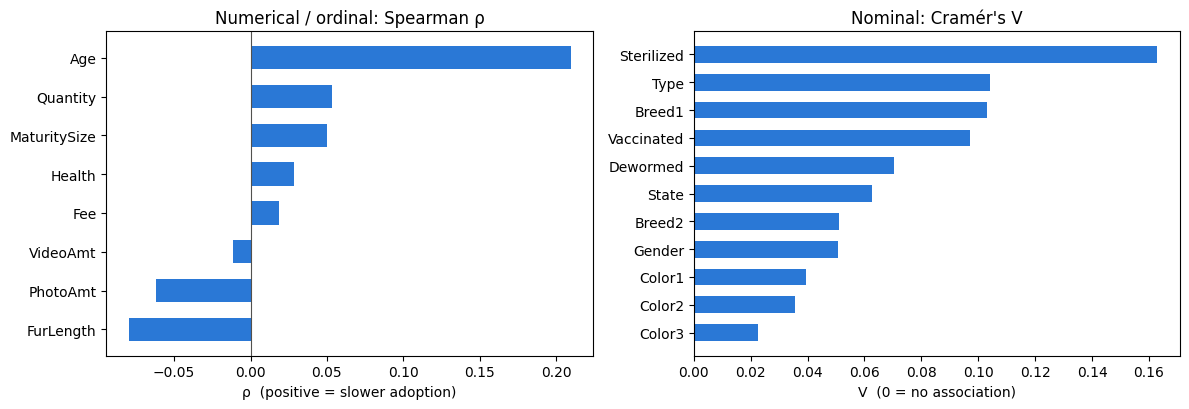

In [ ]:
# Two separate panels: the two measures are different statistics, so they get their own axis
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

axes[0].barh(spearman.index, spearman.values, color='#2a78d6', height=0.6)
axes[0].axvline(0, color='#52514e', linewidth=0.8)        # zero line: left = faster, right = slower adoption
axes[0].set_title('Numerical / ordinal: Spearman ρ')
axes[0].set_xlabel('ρ  (positive = slower adoption)')

axes[1].barh(cramer.index, cramer.values, color='#2a78d6', height=0.6)
axes[1].set_title("Nominal: Cramér's V")
axes[1].set_xlabel('V  (0 = no association)')

plt.tight_layout()
plt.show()

In [ ]:
# Rough common ranking. Both measures run from 0 (no association) upwards,
# so their absolute values give an indicative order - not an exact comparison.
relevance = pd.concat([
    pd.DataFrame({'measure': 'Spearman ρ', 'value': spearman}),
    pd.DataFrame({'measure': "Cramér's V", 'value': cramer}),
])
relevance['strength'] = relevance['value'].abs()          # the sign of ρ only shows the direction
relevance.sort_values('strength', ascending=False).round(3)

,measure,value,strength
Age,Spearman ρ,0.210,0.210
Sterilized,Cramér's V,0.163,0.163
Type,Cramér's V,0.104,0.104
Breed1,Cramér's V,0.103,0.103
Vaccinated,Cramér's V,0.097,0.097
FurLength,Spearman ρ,-0.080,0.080
Dewormed,Cramér's V,0.070,0.070
State,Cramér's V,0.063,0.063
PhotoAmt,Spearman ρ,-0.062,0.062
Quantity,Spearman ρ,0.053,0.053


In [ ]:
def speed_profile(col):
    """Share (%) of each AdoptionSpeed class within each category of one feature,
    plus the mean AdoptionSpeed (lower = faster) and the number of listings."""
    labels = train_readable[col]                                         # readable category names
    profile = (pd.crosstab(labels, train['AdoptionSpeed'], normalize='index') * 100).round(1)
    profile['mean speed'] = train.groupby(labels, observed=True)['AdoptionSpeed'].mean().round(2)
    profile['listings'] = labels.value_counts()
    return profile

speed_profile('Type')

AdoptionSpeed,0,1,2,3,4,mean speed,listings
Type,,,,,,,
Cat,3.5,24.1,27.3,19.1,26.0,2.40,6861
Dog,2.1,17.6,26.6,24.0,29.7,2.62,8132


In [ ]:
# Numerical features have too many distinct values -> group them first, e.g. Age into age bands
train_readable['AgeBand'] = pd.cut(train['Age'], bins=[-1, 2, 6, 12, 36, 300],
                                   labels=['0-2 months', '3-6 months', '7-12 months', '1-3 years', '3+ years'])
speed_profile('AgeBand')

AdoptionSpeed,0,1,2,3,4,mean speed,listings
AgeBand,,,,,,,
0-2 months,3.0,26.0,32.0,22.3,16.7,2.24,5986
3-6 months,2.2,18.9,26.6,22.9,29.4,2.58,4228
7-12 months,2.8,12.9,21.6,20.0,42.6,2.87,1997
1-3 years,3.1,17.1,17.8,19.2,42.8,2.82,1824
3+ years,2.5,17.1,24.7,21.6,34.0,2.68,958
